In [19]:
import numpy as np
from veripulse.pulse import run_grape_si, run_grape, run_crab, PulseConfig, print_pulse_config
from veripulse.gates import rx, rhox, pack_subspace_states, extract_subspace_states, Qobj, operator_to_vector, vector_to_operator
from veripulse.sdp import choi_optimise_secret_indep, calc_secret_indep
from qutip import fidelity
import matplotlib.pyplot as plt
%matplotlib inline

In [120]:
## helpers
def plot_pulse(result):
    final_fidelity_error = result.fid_err
    fig1 = plt.figure()
    ax = fig1.add_subplot(2, 1, 2)
    ax.set_title(f"Optimized Control Sequences: fid_err = {final_fidelity_error:.8e}")
    ax.set_xlabel("Time")
    ax.set_ylabel("Control amplitude")
    ax.step(
        result.time,
        np.hstack((result.final_amps[:, 0], result.final_amps[-1, 0])),
        where="post",
    )
    plt.tight_layout()
    plt.show()

def print_fidelities_si(results, rho_targets):
    """Print fidelity errors in a formatted table."""
    print(f"{'err_Hilbert-Schmidt':>18} {'err_Uhlmann':>18}")
    print("─" * 38)

    K = len(rho_targets)
    err_hs_list = [res.fid_err for res in results]
    err_ul_list = [1- fidelity(vector_to_operator(results[j].evo_full_final), rho_targets[j]) for j in range(K)]
    
    # calculate secret independence
    rho_fin = [vector_to_operator(res.evo_full_final).full() for res in results]
    rho_targ_np = [rho.full() for rho in rho_targets] 
    res_choi = choi_optimise_secret_indep(rho_targ_np, rho_fin)
    
    for i in range(K):
        print(f"{err_hs_list[i]:>18.3e} {err_ul_list[i]:>18.3e}")

    print("─" * 38)
    print("avg:",f"{np.mean(err_hs_list):>13.3e} {np.mean(err_ul_list):>18.3e}")
    print("si :",f"{res_choi.objective:>13.3e}")

def print_fidelities_si_packed(results, angles):
    K = len(angles)
    rtarg = [rhox(t) for t in angles]
    rfin = extract_subspace_states(results, K)

    # calculate secret indep
    solver_opts = {"verbose": False, "eps": 1e-13, "max_iters": 10000}
    si = choi_optimise_secret_indep(rtarg, rfin, solver_opts = solver_opts)

    
    err_fid_ul = [1 - fidelity(Qobj(rtarg[j]), Qobj(rfin[j])) for j in range(K)]
    

# Configurations and target states

In [107]:
conf1 = PulseConfig(omega_drift = 5e6, # 1-10 MHz
                    num_tslots = 100, # number of pulses
                    T2_star = 3e-6, # 
                    evo_time = 2e-7,
                    drive_error = 0.05,
                    detuning = 0.1, # prop to rabi
                    fid_err_scale_factor = 2,
                    fid_err_targ=1e-14, 
                    max_iter=800, 
                    max_wall_time=120) 
print_pulse_config(conf1)

Parameter                      Value Description
─────────────────────────────────────────────
omega_drift                5.000e+06  Hz
T2_star                    3.000e-06  s
drive_error                5.000e-02  
detuning                   1.000e-01  normalised
evo_time                   2.000e-07  s
num_tslots                       100  
amp_lbound                -1.000e+00  
amp_ubound                 1.000e+00  
fid_err_targ               1.000e-14  
max_iter                         800  
max_wall_time                    120  s
init_pulse_type                  RND  
fid_params                        {}  
fid_err_scale_factor               2  


In [22]:
# number of states 
K = 8 
# initial states with a little noise 
err= 1e-4
rho_init = Qobj([[1-err,0],[0,err]])
# target states 
rho_targets = [Qobj(rhox(i*np.pi/4)) for i in range(K)]

# 1 Regular CRAB - most common

In [81]:
result_crab = []
for rho_targ in rho_targets:
    res = run_crab(operator_to_vector(rho_init), operator_to_vector(rho_targ), config=conf1)
    result_crab.append(res)

err_Hilbert-Schmidt        err_Uhlmann
──────────────────────────────────────
         1.109e-03          3.730e-03
         5.472e-03          8.301e-03
         9.664e-02          9.273e-03
         1.384e+00          4.315e-02
         5.638e+00          1.648e-01
         7.101e+00          2.076e-01
         2.395e-01          1.310e-02
         3.181e-03          6.052e-03
──────────────────────────────────────
avg:     1.809e+00          5.701e-02
si: 0.1238585523861527


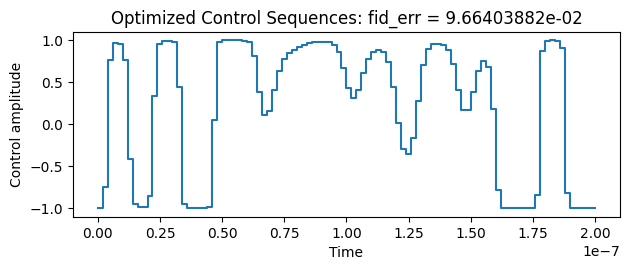

In [98]:
print_fidelities(result_crab, rho_targets)
# calculate secret independence
rho_fin_res1 = [vector_to_operator(res.evo_full_final).full() for res in result_crab]
rho_targ_np = [rho.full() for rho in rho_targets] 
res1_si = choi_optimise_secret_indep(rho_targ_np, rho_fin_res1)
print("si:", res1_si.objective)
plot_pulse(result_crab[2])

# 1 Regular GRAPE

In [108]:
# GRAPE optimisation part
result_grape = []
for rho_targ in rho_targets:
    res = run_grape(operator_to_vector(rho_init), operator_to_vector(rho_targ), config=conf1)
    result_grape.append(res)

In [109]:
print_fidelities_si(result_grape, rho_targets)

err_Hilbert-Schmidt        err_Uhlmann
──────────────────────────────────────
         1.050e-06          2.562e-04
         1.616e-05          1.005e-03
         9.581e-05          2.410e-03
         1.638e-04          3.204e-03
         1.221e-04          2.736e-03
         1.179e-04          2.704e-03
         3.816e-05          1.544e-03
         1.077e-05          7.858e-04
──────────────────────────────────────
avg:     7.071e-05          1.831e-03
si :     1.176e-03


# 2 GRAPE with noise averaging methode

List of results

In [79]:
res8 = []
res4 = []
res2 = []

Pairs of angles that are entirely orthogonal

In [111]:
angles_pair = [(0, np.pi), (np.pi/4, 5*np.pi/4), (np.pi/2, 3*np.pi/2), (3*np.pi/4, 7*np.pi/4)]

## Packing into 8 states at once

In [24]:
# packing states 
K = 8
angles_flat = [x for t in angles_pair for x in t]
vRho_init, vRho_target, U_big = pack_subspace_states(
    rotations = [rx(t) for t in angles_flat],
    rho_init = rho_init,
)

In [17]:
result2 = run_grape_si(vRho_init, vRho_target, U_big, lam=0.01, config=conf2)

Secret Independence =  0.38389255729967864
fidelity error =  0.00023445837308291184
Secret Independence =  0.38361245586996173
fidelity error =  0.00023448495736594008
Secret Independence =  0.38333172084593914
fidelity error =  0.00023451165474272745
Secret Independence =  0.3822057471434125
fidelity error =  0.00023461791487083182
Secret Independence =  0.3782104961145355
fidelity error =  0.0002349847096143299
Secret Independence =  0.37791869578216347
fidelity error =  0.0002350135330154727
Secret Independence =  0.3767485183897127
fidelity error =  0.0002351282694342632
Secret Independence =  0.37202190075681896
fidelity error =  0.00023557830468913228
Secret Independence =  0.3643182069983484
fidelity error =  0.00023626883271585654
Secret Independence =  0.3639994085464732
fidelity error =  0.00023630276104429575
Secret Independence =  0.3627214088545284
fidelity error =  0.00023643781020535838
Secret Independence =  0.35756655156916073
fidelity error =  0.00023696738160706055
S

In [284]:
rho_fin_res2=extract_subspace_states(result2, K)

NameError: name 'result2' is not defined

In [41]:
solver_opts = {"verbose": False, "eps": 1e-10, "max_iters": 10000}
res2_si = choi_optimise_secret_indep(rho_targ_np, rho_fin_res2, solver_opts=solver_opts)

In [67]:
res2_si.objective

np.float64(0.0025797196397621797)

In [43]:
res2_si.status

'optimal'

## Packing into 4 states at once

## batch 1

In [112]:
angles4_batch1 = [t[0] for t in angles_pair]

In [113]:
vRho_init, vRho_target, U_big = pack_subspace_states(
    rotations=[rx(t) for t in angles4_batch1],
    rho_init=rho_init,
)

In [114]:
res4_split1 = run_grape_si(vRho_init, vRho_target, U_big, lam=80, config=conf1)

/users/home/gustiani/VeriPulse/src/veripulse/pulse.py:234: FutureWarning: The 'fid_err_scale_factor' parameter is deprecated. Use 'scale_factor' in fid_params instead
  return cpo.optimize_pulse(


Secret Independence =  0.27655389729774327
fidelity error =  0.2453665471903294
Secret Independence =  0.45210955091356836
fidelity error =  0.19718701113823162
Secret Independence =  0.02365665988575995
fidelity error =  0.2196455975890964
Secret Independence =  0.059063603600176776
fidelity error =  0.20865702486552887
Secret Independence =  0.0025276434856023123
fidelity error =  0.21409737515611926
Secret Independence =  9.843588121423281e-05
fidelity error =  0.21112610571158524
Secret Independence =  2.0480476423123392e-05
fidelity error =  0.20836876256124168
Secret Independence =  2.4549493129376043e-05
fidelity error =  0.2055775296813002
Secret Independence =  0.00028129654232209023
fidelity error =  0.164657733670657
Secret Independence =  0.0006285385023403002
fidelity error =  0.10670959517691926
Secret Independence =  0.001585970909386648
fidelity error =  0.0023077043848259374
Secret Independence =  0.0005441306403409182
fidelity error =  0.0028346000223222626
Secret Ind

In [121]:
rtarg = [rhox(t) for t in angles4_batch1]
rfin = extract_subspace_states(res4_split1, 4)
solver_opts = {"verbose": False, "eps": 1e-13, "max_iters": 10000}
si_split1 = choi_optimise_secret_indep(rtarg, rfin, solver_opts = solver_opts)

In [123]:
print(si_split1.status)
si_split1.objective

optimal


np.float64(0.000537258173056324)

In [124]:
calc_secret_indep(si_split1.choi, rtarg, rfin)

np.float64(0.0005372581731027449)

In [118]:
for j in range(len(rtarg)):
    print(1 - fidelity(Qobj(rtarg[j]), Qobj(rfin[j])))

0.0027548623268899286
0.0034131976299075495
0.002381429209983521
0.003437381463086031


/users/home/gustiani/VeriPulse/.venv/lib/python3.14/site-packages/qutip/core/data/expm.py:146: LinAlgWarning: Matrix is singular. The result might be inaccurate or the array might not have a square root.
  return Dense(scipy.linalg.sqrtm(matrix.as_ndarray()))


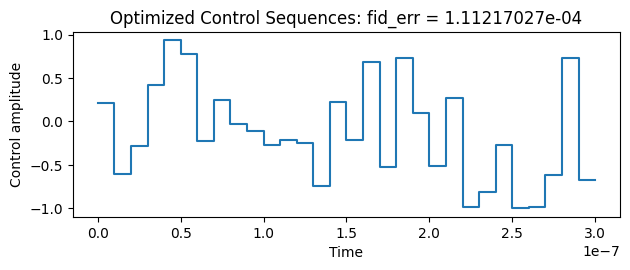

In [243]:
plot_pulse(res4_split1)